In [1]:
import os
from  pathlib import Path
from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten, BatchNormalization as Normalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:

drive.mount('/content/drive')

In [ ]:
os.listdir('/content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs')

In [ ]:
DATASET_PATH= Path('/content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs')

In [ ]:
print(DATASET_PATH.exists())
print(f"DATASET_PATH: {DATASET_PATH}")

#Create two ImageDataGenerator objects.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)




In [ ]:
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_datagen

In [ ]:
dir(train_datagen)

#Then create the generators: one for traning , one for validation

In [ ]:
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="training",
    shuffle=True
)

In [11]:
validation_generator = validation_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 400 images belonging to 2 classes.


In [32]:
print(train_generator.class_indices)
print(validation_generator.class_indices)

{'cats': 0, 'dogs': 1}
{'cats': 0, 'dogs': 1}


In [33]:
print("Training Images:", train_generator.samples)
print("Validation Images:", validation_generator.samples)

Training Images: 1600
Validation Images: 400


In [39]:
import numpy as np

labels = train_generator.classes

print(np.bincount(labels))

[800 800]


In [41]:
import numpy as np

labels = validation_generator.classes

print(np.bincount(labels))

[200 200]


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step
[[0.07591157]
 [0.07477034]
 [0.07609516]
 [0.06474545]
 [0.09274156]
 [0.07244292]
 [0.08070212]
 [0.07232431]
 [0.06756864]
 [0.06974668]
 [0.06936666]
 [0.08452733]
 [0.08267473]
 [0.08265362]
 [0.07025817]
 [0.06733669]
 [0.07793246]
 [0.06348477]
 [0.07552242]
 [0.07486667]]


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step
[[0.07060889]
 [0.07029077]
 [0.07870874]
 [0.07441268]
 [0.08092812]
 [0.08641958]
 [0.07928085]
 [0.07639471]
 [0.07586399]
 [0.07909163]
 [0.07285056]
 [0.06921385]
 [0.08006024]
 [0.07862842]
 [0.07738469]
 [0.06859965]
 [0.08346988]
 [0.07215462]
 [0.07111457]
 [0.07013266]]


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step
Image 381 Actual=1 Predicted=0 Probability=0.0706
Image 382 Actual=1 Predicted=0 Probability=0.0703
Image 383 Actual=1 Predicted=0 Probability=0.0787
Image 384 Actual=1 Predicted=0 Probability=0.0744
Image 385 Actual=1 Predicted=0 Probability=0.0809
Image 386 Actual=1 Predicted=0 Probability=0.0864
Image 387 Actual=1 Predicted=0 Probability=0.0793
Image 388 Actual=1 Predicted=0 Probability=0.0764
Image 389 Actual=1 Predicted=0 Probability=0.0759
Image 390 Actual=1 Predicted=0 Probability=0.0791
Image 391 Actual=1 Predicted=0 Probability=0.0729
Image 392 Actual=1 Predicted=0 Probability=0.0692
Image 393 Actual=1 Predicted=0 Probability=0.0801
Image 394 Actual=1 Predicted=0 Probability=0.0786
Image 395 Actual=1 Predicted=0 Probability=0.0774
Image 396 Actual=1 Predicted=0 Probability=0.0686
Image 397 Actual=1 Predicted=0 Probability=0.0835
Image 398 Actual=1 Predicted=0 Probability=0.0722
Image 399 Actual=1 Predicted=0 Probability=0.0711
Image 400

## 📌 Training Generator vs Validation Generator

Although both generators read images from the same dataset, **their purposes are different**, so their configurations should also be different.

| Configuration | Training Generator | Validation Generator | Reason |
|---------------|-------------------|----------------------|--------|
| `rescale=1./255` | ✅ Yes | ✅ Yes | Normalize pixel values to the range [0,1]. |
| `rotation_range` | ✅ Yes | ❌ No | Helps the model learn from rotated images. Validation images should remain unchanged. |
| `horizontal_flip` | ✅ Yes | ❌ No | Improves robustness to left-right variations during training. |
| `zoom_range` | ✅ Yes | ❌ No | Makes the model robust to objects appearing at different scales. |
| `brightness_range` | ✅ Optional | ❌ No | Simulates different lighting conditions only during training. |
| `shear_range` | ✅ Optional | ❌ No | Introduces geometric variations during training. |
| `shuffle` | ✅ Yes | Usually ❌ No | Training benefits from random batches. Validation should remain consistent for fair evaluation. |

Validation: We don't need randomness.

We simply evaluate the same validation set each epoch.

---



In [12]:
dir(train_generator)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__next__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_api_export_path',
 '_api_export_symbol_id',
 '_filepaths',
 '_flow_index',
 '_get_batches_of_transformed_samples',
 '_max_queue_size',
 '_set_index_array',
 '_use_multiprocessing',
 '_warn_if_super_not_called',
 '_workers',
 'allowed_class_modes',
 'batch_index',
 'batch_size',
 'class_indices',
 'class_mode',
 'classes',
 'color_mode',
 'data_format',
 'directory',
 'dtype',
 'filenames',
 'filepaths',
 'image_data_generator',
 'image_shape',
 'index_array',
 'index_generator',
 'interpolation',
 'keep_aspect_ratio',
 'labels',
 'lock',
 'max_queue_

In [13]:
train_generator.class_indices

{'cats': 0, 'dogs': 1}

In [14]:
train_generator.color_mode

'rgb'

In [15]:
train_generator.image_shape

(224, 224, 3)

In [16]:
print(len(train_generator))

50


In [17]:
vars(train_datagen)

{'featurewise_center': False,
 'samplewise_center': False,
 'featurewise_std_normalization': False,
 'samplewise_std_normalization': False,
 'zca_whitening': False,
 'zca_epsilon': 1e-06,
 'rotation_range': 20,
 'width_shift_range': 0.0,
 'height_shift_range': 0.0,
 'shear_range': 0.0,
 'zoom_range': [0.8, 1.2],
 'channel_shift_range': 0.0,
 'fill_mode': 'nearest',
 'cval': 0.0,
 'horizontal_flip': True,
 'vertical_flip': False,
 'rescale': 0.00392156862745098,
 'preprocessing_function': None,
 'dtype': 'float32',
 'interpolation_order': 1,
 'data_format': 'channels_last',
 'channel_axis': 3,
 'row_axis': 1,
 'col_axis': 2,
 '_validation_split': 0.2,
 'mean': None,
 'std': None,
 'zca_whitening_matrix': None,
 'brightness_range': None}

1600 images
──────────── = 50 batches
32 images/batch

In [18]:
images, labels = next(train_generator)

In [19]:
print(f"image shape:{images.shape} label shape:{labels.shape}")


image shape:(32, 224, 224, 3) label shape:(32,)


In [20]:
labels[:5]

array([1., 0., 1., 1., 0.], dtype=float32)

(32, 224, 224, 3)
 │    │    │    │
 │    │    │    └── Channels (RGB)
 │    │    └────── Width
 │    └─────────── Height
 └──────────────── Number of Images (Batch Size)

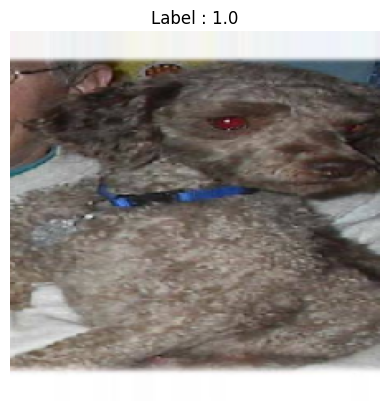

In [21]:
import matplotlib.pyplot as plt

plt.imshow(images[0])
plt.title(f"Label : {labels[0]}")
plt.axis("off")
plt.show()

In [22]:
print(type(images))
print(type(labels))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


## 📌 What does ImageDataGenerator return?

When we execute:

```python
images, labels = next(train_generator)
```

the `ImageDataGenerator` reads one batch of images from the dataset and returns **two NumPy arrays**.

### Data Flow

```text
Image Files (.jpg)

        │
        ▼

ImageDataGenerator

        │
        ▼

Image Preprocessing
• Resize Images
• Rescale Pixel Values
• (Optional) Data Augmentation

        │
        ▼

NumPy Arrays

        │
        ├── images → Shape : (32, 224, 224, 3)
        │
        └── labels → Shape : (32,)

        │
        ▼

model.fit()

        │
        ▼

TensorFlow internally converts NumPy arrays into Tensors

        │
        ▼

CNN
```

---

### Understanding `images.shape`

```python
images.shape
```

Output

```python
(32, 224, 224, 3)
```

Meaning

| Dimension | Meaning |
|-----------|---------|
| 32 | Number of images in one batch (Batch Size) |
| 224 | Image Height |
| 224 | Image Width |
| 3 | RGB Channels |

---

### Understanding `labels.shape`

```python
labels.shape
```

Output

```python
(32,)
```

Meaning

- One label for each image in the batch.
- Since this is a binary classification problem (`cats` vs `dogs`), labels are stored as:

```text
Cat  → 0
Dog  → 1
```

Example

```python
[0., 1., 0., 1., 1., 0., ...]
```

---

### Important Observation

`ImageDataGenerator` **does not return TensorFlow tensors**.

It returns **NumPy arrays**.

During

```python
model.fit(train_generator)
```

TensorFlow automatically converts these NumPy arrays into tensors before feeding them into the CNN.

---

### Learning Summary

```text
Image Files (.jpg)

        ↓

ImageDataGenerator

        ↓

NumPy Arrays

        ↓

TensorFlow

        ↓

Tensor

        ↓

CNN
```

> **Note:** `ImageDataGenerator` is part of TensorFlow's **legacy preprocessing API**, which is why it produces NumPy arrays. In modern TensorFlow pipelines, `tf.data.Dataset` returns TensorFlow tensors directly.

Momentum is an optimization technique used with SGD to speed up training.

Without Momentum:
• The optimizer updates weights using only the current gradient.
• Training can be slow and may oscillate while approaching the minimum.

With Momentum:
• The optimizer remembers a fraction of the previous update and combines it with the current update.
• This helps move faster in the correct direction.
• Reduces oscillations.
• Often leads to faster convergence and better training stability.

Common values:
• momentum = 0.9 (most commonly used)
• momentum = 0.95
• momentum = 0.99

In [23]:
def CNN_MODEL(filter1, filter2,filter3,dense_units,l2_reg,dropout,learning_rate,momentum):
    model= Sequential(
        [
            Conv2D(filter1,(3,3),activation='relu',input_shape=(224,224,3),kernel_regularizer=regularizers.l2(l2_reg)),
            Normalization(),
            MaxPooling2D((2,2)),
            Dropout(dropout),

            Conv2D(filter2,(3,3),activation='relu',kernel_regularizer=regularizers.l2(l2_reg)),
            Normalization(),
            MaxPooling2D((2,2)),
            Dropout(dropout),

            Conv2D(filter3,(3,3),activation='relu',kernel_regularizer=regularizers.l2(l2_reg)),
            Normalization(),
            MaxPooling2D((2,2)),
            Dropout(dropout),

            Flatten(),
            Dense(dense_units,activation='relu',kernel_regularizer=regularizers.l2(l2_reg)),
            Dropout(dropout),
            Dense(1,activation='sigmoid')

        ])

    optimizer= SGD(learning_rate=learning_rate, momentum=momentum)
    model.compile(
               optimizer=optimizer,
               loss='binary_crossentropy',
               metrics=['accuracy']
               )


    return model





In [24]:
model=CNN_MODEL(32,164,128,256,0.001,0.30,0.0001,0.9)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


we had tried wth learnin rate 0.0001 the accuracy is very low lets us chnge the accuracy from 0.001 to 0.1  momentum=0.9 Momentum helps SGD converge much faster.
learning_rate = 0.0001

Characteristics:

Small weight updates.
Slow convergence.
Requires more epochs to reach the optimal solution.
Less chance of overshooting the minimum.
Training may appear to improve very slowly.

Example:

Epoch 1  → Accuracy = 55%
Epoch 20 → Accuracy = 63%
Epoch 50 → Accuracy = 68%
Large Learning Rate
learning_rate = 0.01

Characteristics:

Large weight updates.
Faster learning.
Can reach good accuracy in fewer epochs.
If too large, training may become unstable and fail to converge.

Example:

Epoch 1 → Accuracy = 55%
Epoch 5 → Accuracy = 72%
Epoch 10 → Accuracy = 80%

If the learning rate is too large, the optimizer may overshoot the minimum loss,causing the loss to oscillate or even increase.

Define the Save Path

In [ ]:
MODEL_DIR = Path("/content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/saved_models")

MODEL_DIR.mkdir(parents=True, exist_ok=True)

##ModelCheckpoint

In [26]:
checkpoint = ModelCheckpoint(
    filepath=MODEL_DIR / "best_cats_dogs_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

#EarlyStopping

In [27]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

#Reduce Learning Rate

In [28]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

What is inside train_generator?

Not just images.It already contains

Images-->Labels-->Batch Information-->Shuffle Information-->Rescaling-->Augmentation

In [29]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPUs Available:", tf.config.list_physical_devices('GPU'))
print("CPUs Available:", tf.config.list_physical_devices('CPU'))

TensorFlow Version: 2.20.0
GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPUs Available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [30]:
history=model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.5336 - loss: 1.8759 
Epoch 1: val_loss improved from None to 2.03798, saving model to /content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/saved_models/best_cats_dogs_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/saved_models/best_cats_dogs_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 799s 16s/step - accuracy: 0.5550 - loss: 1.7823 - val_accuracy: 0.5000 - val_loss: 2.0380 - learning_rate: 1.0000e-04
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - accuracy: 0.5925 - loss: 1.4697
Epoch 2: val_loss did not improve from 2.03798
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 666ms/step - accuracy: 0.6075 - loss: 1.4426 - val_accuracy: 0.5000 - val_loss: 2.9813 - learning_rate: 1.0000e-04
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.6004 - loss: 1.4092
Epoch 3: val_loss did not improve from 2.03798
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 567ms/step - accuracy: 0.6075 -

In [ ]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "/content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/training_history.csv",
    index=False
)

In [ ]:
history_df = pd.read_csv(
    "/content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/training_history.csv"
)

In [ ]:
model.summary()

What happens internally? Suppose the CNN asks"Give me the next batch."

TensorFlow internally does something like images, labels = next(train_generator)

which returns images.shape (32,224,224,3) labels.shape:(32,)

The CNN immediately trains on that batch. Then it asks again.next(train_generator)

Next batch. Again. next(train_generator)

Next batch.

This continues until all batches in one epoch are processed.

In [44]:
validation_generator.reset()

predictions = model.predict(validation_generator)

print(predictions[:20])

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step
[[0.07591157]
 [0.07477034]
 [0.07609516]
 [0.06474545]
 [0.09274156]
 [0.07244292]
 [0.08070212]
 [0.07232431]
 [0.06756864]
 [0.06974668]
 [0.06936666]
 [0.08452733]
 [0.08267473]
 [0.08265362]
 [0.07025817]
 [0.06733669]
 [0.07793246]
 [0.06348477]
 [0.07552242]
 [0.07486667]]


In [45]:
validation_generator.reset()

predictions = model.predict(validation_generator)

print(predictions[-20:])

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step
[[0.07060889]
 [0.07029077]
 [0.07870874]
 [0.07441268]
 [0.08092812]
 [0.08641958]
 [0.07928085]
 [0.07639471]
 [0.07586399]
 [0.07909163]
 [0.07285056]
 [0.06921385]
 [0.08006024]
 [0.07862842]
 [0.07738469]
 [0.06859965]
 [0.08346988]
 [0.07215462]
 [0.07111457]
 [0.07013266]]


In [46]:
validation_generator.reset()

predictions = model.predict(validation_generator)

predicted_classes = (predictions >= 0.5).astype(int).flatten()

actual_classes = validation_generator.classes

for i in range(380, 400):
    print(
        f"Image {i+1}",
        f"Actual={actual_classes[i]}",
        f"Predicted={predicted_classes[i]}",
        f"Probability={predictions[i][0]:.4f}"
    )

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step
Image 381 Actual=1 Predicted=0 Probability=0.0706
Image 382 Actual=1 Predicted=0 Probability=0.0703
Image 383 Actual=1 Predicted=0 Probability=0.0787
Image 384 Actual=1 Predicted=0 Probability=0.0744
Image 385 Actual=1 Predicted=0 Probability=0.0809
Image 386 Actual=1 Predicted=0 Probability=0.0864
Image 387 Actual=1 Predicted=0 Probability=0.0793
Image 388 Actual=1 Predicted=0 Probability=0.0764
Image 389 Actual=1 Predicted=0 Probability=0.0759
Image 390 Actual=1 Predicted=0 Probability=0.0791
Image 391 Actual=1 Predicted=0 Probability=0.0729
Image 392 Actual=1 Predicted=0 Probability=0.0692
Image 393 Actual=1 Predicted=0 Probability=0.0801
Image 394 Actual=1 Predicted=0 Probability=0.0786
Image 395 Actual=1 Predicted=0 Probability=0.0774
Image 396 Actual=1 Predicted=0 Probability=0.0686
Image 397 Actual=1 Predicted=0 Probability=0.0835
Image 398 Actual=1 Predicted=0 Probability=0.0722
Image 399 Actual=1 Predicted=0 Probability=0.0711
Image 400